# ***<span style="color:red"> ***************** Machine Learning  *****************         </span>***
# <span style="color:green">***Enas Khamis Mraish </span>***
# ***<span style="color:green">2320221198</span>***
# ***<span style="color:green">Lecturer : Ibrahim O. Kaware </span>***
# ***<span style="color:green">ASS 1 </span>***

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#  ***<span style="color:blue"> Task 1 :  Data Retrieval</span>***
##   ***<span style="color:green"> Loading Data Set</span>***
### In this step, I import the necessary libraries and load the datasets. It is crucial to check the shape and the first 5 rows to understand the feature space and identify potential issues like missing values right from the start.


In [3]:
# Loading the datasets from CSV files
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

##   ***<span style="color:green"> Dataset Inspection</span>***


In [4]:
# Checking the number of rows and columns
train_df.shape
train_df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
test_df.shape

(1459, 80)

##   ***<span style="color:green"> Memory Management</span>***
### To ensure efficient processing, I optimized the dataset's memory usage. I converted categorical string columns into the category dtype and downcasted numerical features like LotFrontage to float32. This significantly reduces the memory footprint while maintaining data integrity, which is a best practice for handling large datasets in machine learning.


In [12]:
train_df.dtypes.value_counts()

object     43
int64      35
float64     3
Name: count, dtype: int64

In [54]:
# Converting specific object columns to category to save memory
optimized_dtypes = {
    'MSZoning': 'category',
    'Street': 'category',
    'LotShape': 'category'
}
train_df = train_df.astype(optimized_dtypes) 
test_df = test_df.astype(optimized_dtypes)

# Automatically converting all remaining 'object' columns to 'category'
for col in train_df.select_dtypes(include=['object']).columns:
    train_df[col] = train_df[col].astype('category') 
    test_df[col] = test_df[col].astype('category') 

# Downcasting float64 to float32 (Downcasting) for memory efficiency
train_df['LotFrontage'] = pd.to_numeric(train_df['LotFrontage'], downcast='float')
test_df['LotFrontage'] = pd.to_numeric(test_df['LotFrontage'], downcast='float') 

In [25]:
# Displaying updated info to verify memory reduction
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   int64   
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1201 non-null   float32 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   category
 6   Alley          91 non-null     category
 7   LotShape       1460 non-null   category
 8   LandContour    1460 non-null   category
 9   Utilities      1460 non-null   category
 10  LotConfig      1460 non-null   category
 11  LandSlope      1460 non-null   category
 12  Neighborhood   1460 non-null   category
 13  Condition1     1460 non-null   category
 14  Condition2     1460 non-null   category
 15  BldgType       1460 non-null   category
 16  HouseStyle     1460 non-null   category
 17  OverallQual    1460 non-null   in

#  ***<span style="color:blue"> Task 2 :Data Cleaning </span>***
##   ***<span style="color:green">Missing Value Analysis</span>***
### Many features have a high percentage of missing values. However, in this dataset, 'NaN' often means the feature is not present (e.g., No Pool, No Fence). I replace these with the string 'None' to prevent the model from treating them as unknown errors, which preserves the categorical information.


In [34]:
train_df['PoolQC'].isna().sum()

np.int64(0)

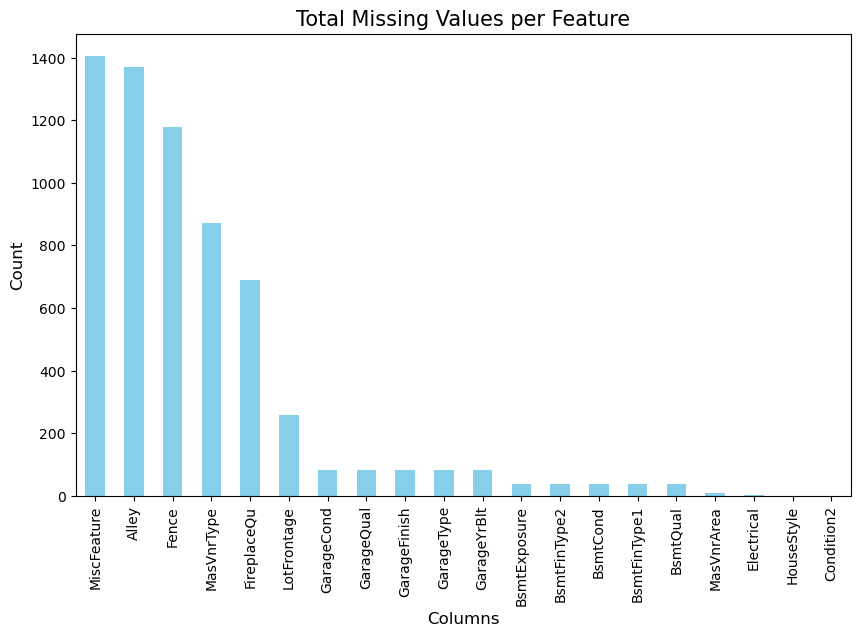

In [35]:
total = train_df.isnull().sum().sort_values(ascending=False)
total_select = total.head(20) 

plt.figure(figsize=(10, 6))
total_select.plot(kind="bar", color='skyblue')
plt.title("Total Missing Values per Feature", fontsize=15)
plt.xlabel("Columns", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

In [43]:
# List of columns where NaN means 'None'
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

for col in none_cols:
    if col in train_df.columns:
        # Fill missing values with 'None' string
        train_df[col] = train_df[col].astype(object).fillna('None')
        
    if col in test_df.columns:
        test_df[col] = test_df[col].astype(object).fillna('None')

print(train_df[none_cols].isnull().sum())

PoolQC         0
MiscFeature    0
Alley          0
Fence          0
dtype: int64


##   ***<span style="color:green">Outlier Removal</span>***
## We drop the "weird" houses that are huge but super cheap. These outliers mess up our math and confuse the model.


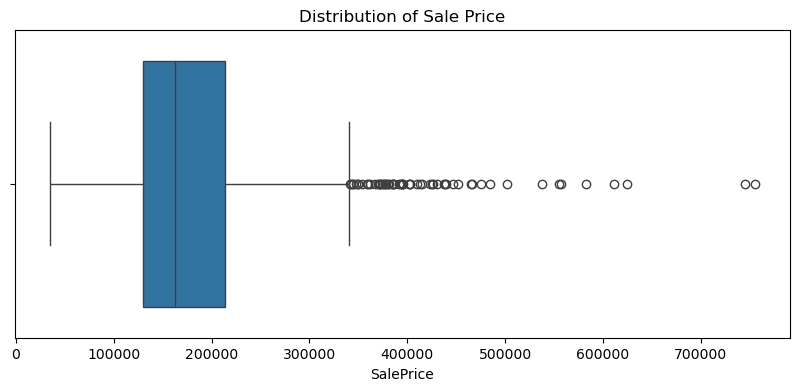

In [44]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=train_df['SalePrice'])
plt.title('Distribution of Sale Price')
plt.show()

1182    4476
691     4316
Name: GrLivArea, dtype: int64


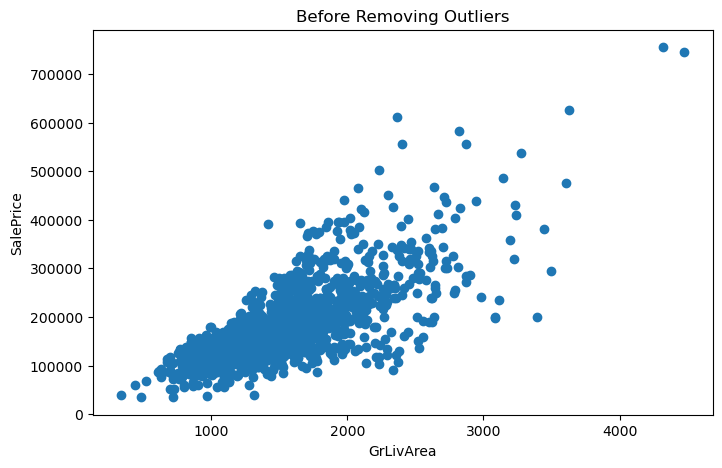

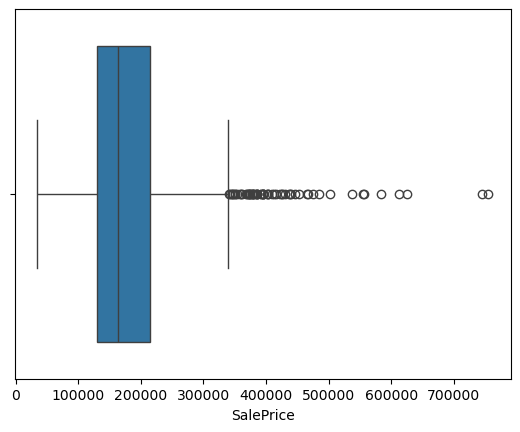

In [46]:
print(train_df['GrLivArea'].sort_values(ascending=False).head(2))

plt.figure(figsize=(8, 5))
plt.scatter(x=train_df['GrLivArea'], y=train_df['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.title('Before Removing Outliers')
plt.show()
sns.boxplot(x=train_df['SalePrice'])
plt.show()

# Identify indices of extreme outliers (Large area, low price)
outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)].index

# Drop these outliers from the training set
train_df = train_df.drop(outliers)



##   ***<span style="color:green">Data Transformation ' logarithmic transformation'</span>***

### The SalePrice distribution is right-skewed. Most linear models perform better on normally distributed data. I applied the Log Transformation (log1p) to make the distribution more Bell-Shaped. This ensures that the model treats percentage errors equally across different price ranges.


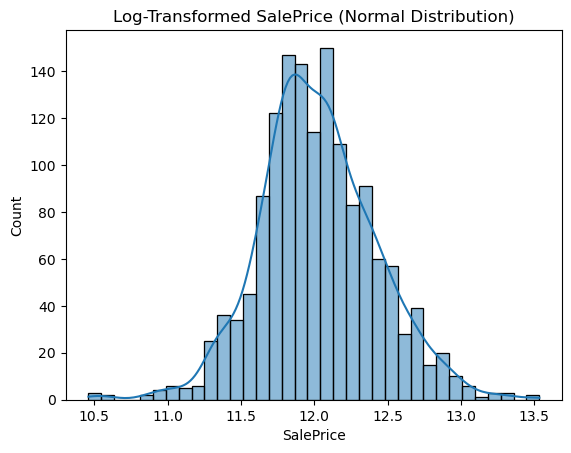

In [47]:
# Apply Log transformation to stabilize the variance
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

# Visualize the new normal distribution
sns.histplot(train_df['SalePrice'], kde=True)
plt.title('Log-Transformed SalePrice (Normal Distribution)')
plt.show()

#  ***<span style="color:blue"> Task 3 : Exploratory Data Analysis (EDA)</span>***
##   ***<span style="color:green">Correlation Analysis ' Using a heatmap to identify the top 5 features most strongly correlated with SalePrice '</span>***
### To understand which features have the strongest impact on house prices, I calculated the correlation matrix. Using a Heatmap , I identified the top 5 numerical features most strongly correlated with SalePrice. This helps in prioritizing features for the prediction model.


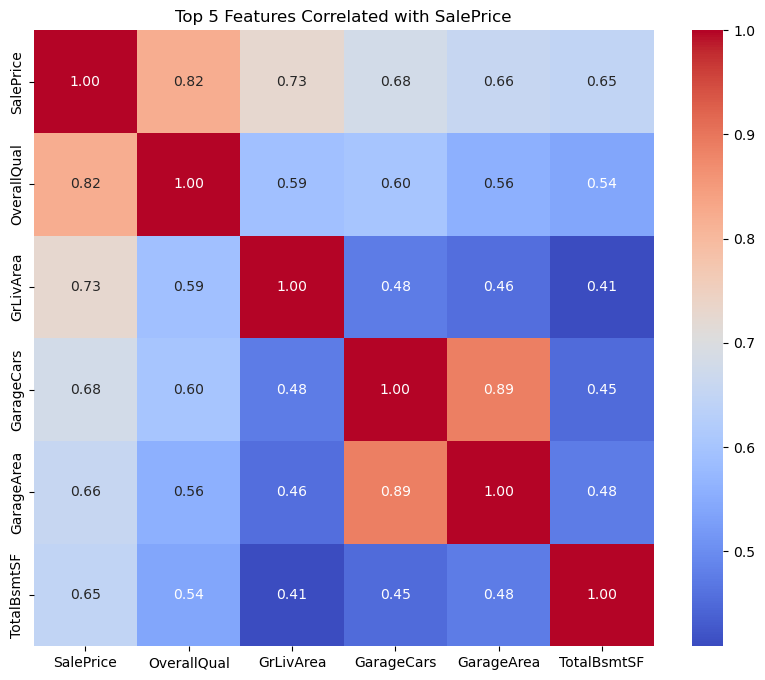

In [48]:
# Select only numerical columns for correlation calculation
corr_matrix = train_df.select_dtypes(include=['number']).corr()

# Extract top 5 features correlated with SalePrice (excluding itself)
top_5_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(6).index

plt.figure(figsize=(10, 8))

# Plot the heatmap to visualize relationships
sns.heatmap(train_df[top_5_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Top 5 Features Correlated with SalePrice')
plt.show()

##   ***<span style="color:green">Visual Exploration ' The relationship between GrLivArea (Above grade (ground) living area square feet) and SalePrice, colored by OverallQual'</span>***
### I created a scatter plot to visualize how GrLivArea (Living Area) affects SalePrice. By coloring the points based on OverallQual, I discovered a clear pattern: larger homes generally cost more, but High Quality (Yellow/Green points) significantly boosts the price even for smaller areas.


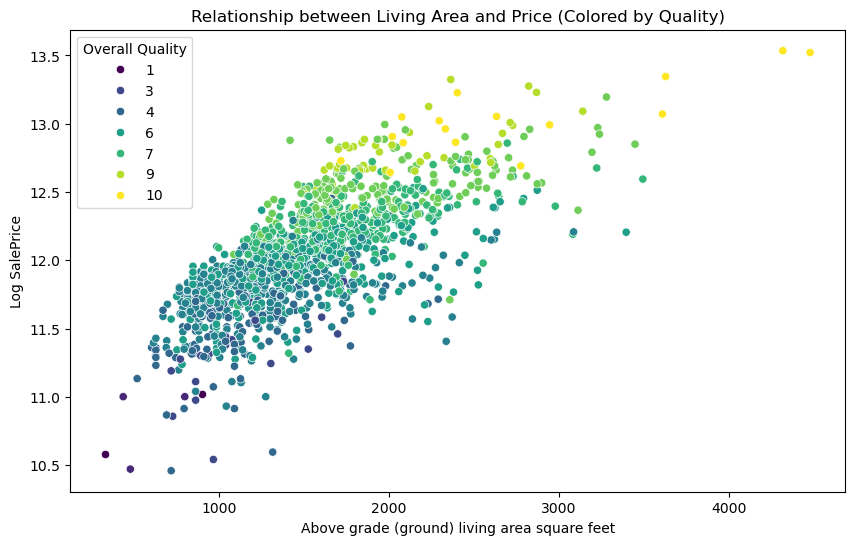

In [49]:
plt.figure(figsize=(10, 6))

# Scatter plot with 'hue' to show the impact of Quality
sns.scatterplot(data=train_df, x='GrLivArea', y='SalePrice', hue='OverallQual', palette='viridis')
plt.title('Relationship between Living Area and Price (Colored by Quality)')
plt.xlabel('Above grade (ground) living area square feet')
plt.ylabel('Log SalePrice')
plt.legend(title='Overall Quality')
plt.show()

##   ***<span style="color:green">Geographical Insights ' The average SalePrice across different Neighborhood values'</span>***
### Location is everything in real estate. This bar chart shows the average (Log) SalePrice for each neighborhood. Sorting them reveals which areas are the most expensive (e.g., NoRidge, NridgHt) versus more affordable ones, which is a vital insight for the model's spatial understanding.


C:\Users\top\AppData\Local\Temp\ipykernel_1052\2451234155.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  neighborhood_prices = train_df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
C:\Users\top\AppData\Local\Temp\ipykernel_1052\2451234155.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neighborhood_prices.index, y=neighborhood_prices.values, palette='magma')


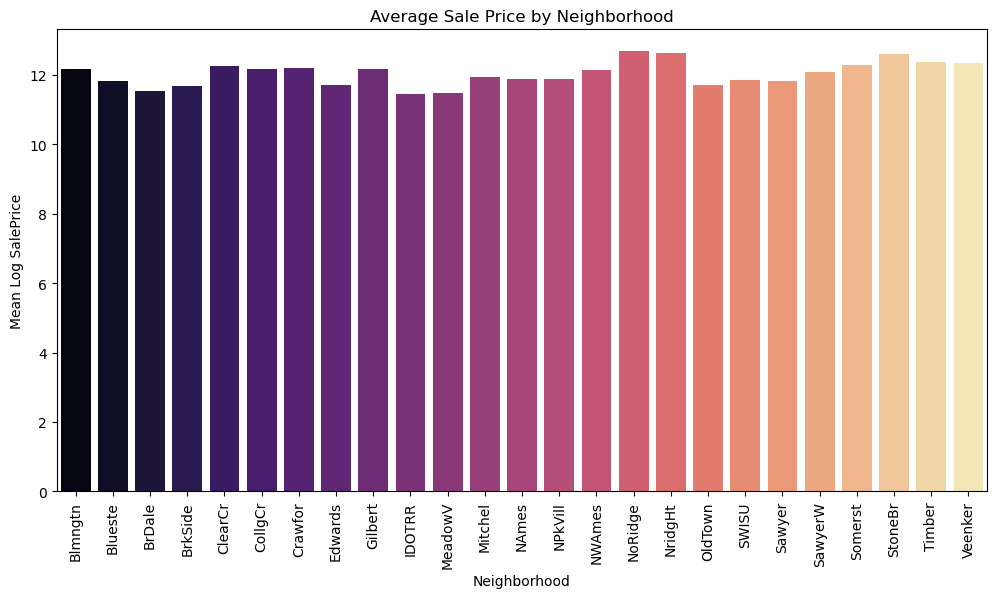

In [50]:
# Grouping by Neighborhood and calculating the mean price
neighborhood_prices = train_df.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))

# Plotting the averages using a bar plot
sns.barplot(x=neighborhood_prices.index, y=neighborhood_prices.values, palette='magma')
plt.xticks(rotation=90)
plt.title('Average Sale Price by Neighborhood')
plt.ylabel('Mean Log SalePrice')
plt.xlabel('Neighborhood')
plt.show()

#  ***<span style="color:blue"> Task 4 : Feature Engineering</span>***
### In this final step, I built a robust preprocessing pipeline to ensure consistent transformations across both training and testing sets. This phase includes:
## ***<span style="color:green"> Feature Transformation:</span>***
### Combining basement and floor areas into a single TotalSF feature to capture total living space.

##  ***<span style="color:green"> Encoding Categorical Variables:</span>***
### Applying Label Encoding for ordinal features (like Quality) and One-Hot Encoding for nominal features (like Neighborhood).

##  ***<span style="color:green"> Pipeline Construction:</span>***
###  Aligning the columns of both datasets to ensure they are identical before feeding them into the machine learning model.

In [17]:
# Function to automate all preprocessing steps consistently
def clean_and_prepare(df):
    data = df.copy()
    
      # 1. Fill specific missing categorical values with 'None'  
    for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence']:
        if col in data.columns:
            data[col] = data[col].astype(object).fillna('None')

        # 2. Create TotalSF: A very important predictor for house prices
    data['TotalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']
    
   
       # 3. Ordinal Encoding: Converting quality strings into a numerical rank
    m = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
    data['ExterQual'] = data['ExterQual'].map(m).fillna(0)
    data['KitchenQual'] = data['KitchenQual'].map(m).fillna(0)
     
        # 4. Nominal Encoding: Creating dummy variables for the model
    data = pd.get_dummies(data, columns=['Neighborhood', 'BldgType'], drop_first=True)

    # 5. Fill remaining numerical NaNs with the median
    num = data.select_dtypes(include=[np.number]).columns
    data[num] = data[num].fillna(data[num].median())
    return data

train_final = clean_and_prepare(train_df)
test_final = clean_and_prepare(test_df)

missing_cols = set(train_final.columns) - set(test_final.columns)
for c in missing_cols:
    if c != 'SalePrice':
       test_final[c] = 0
        
final = [c for c in train_final.columns if c != 'SalePrice' and c != 'Id']
x = train_final[final]
y = train_final['SalePrice']
x_test = test_final[final]

In [26]:
# Verify alignment: Ensuring X and X_test have identical columns
print(f"{x.shape}")
print(f"{x_test.shape}")
if list(x.columns) == list(x_test.columns):
    print('success')
else:
    print('fail')

(1460, 106)
(1459, 106)
success


In [29]:
train_final.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1460.0,69.863699,22.027677,21.0,60.00,69.0,79.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1460.0,103.117123,180.731373,0.0,0.00,0.0,164.25,1600.0
ExterQual,1460.0,3.395890,0.574280,2.0,3.00,3.0,4.00,5.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
